# Time Series Plot

Contributions from Landon Moeller and Caitlin Roufa

In [1]:
#importing packages
import pandas as pd
import glob
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import matplotlib.dates as mdates
from scipy.ndimage import gaussian_filter1d

In [2]:
#load data epochs
df_HIST = pd.concat(map(pd.read_csv, glob.glob('/home/scratch/jcorner1/syn_sev/dataframes/HIST_UVV_[21]*_*')), ignore_index=True)
df_8p5END = pd.concat(map(pd.read_csv, glob.glob('/home/scratch/jcorner1/syn_sev/dataframes/EOC8p5_UVV*')), ignore_index=True)
df_4p5END = pd.concat(map(pd.read_csv, glob.glob('/home/scratch/jcorner1/syn_sev/dataframes/EOC4p5_UVV*')), ignore_index=True)
df_8p5MID = pd.concat(map(pd.read_csv, glob.glob('/home/scratch/jcorner1/syn_sev/dataframes/MC8p5_UVV*')), ignore_index=True)
df_4p5MID = pd.concat(map(pd.read_csv, glob.glob('/home/scratch/jcorner1/syn_sev/dataframes/MC4p5_UVV*')), ignore_index=True)

In [3]:
# threshold and assign datetime HIST
df_HIST = df_HIST[((df_HIST['DBZ'] >= 40.0) & (df_HIST['UVV'] >= 25.0))]
df_HIST['Time'] = pd.to_datetime(df_HIST['Time'])
df_HIST['Date'] = pd.to_datetime(df_HIST['Time']).dt.date
df_HIST['Year'] = pd.to_datetime(df_HIST['Time']).dt.year
df_HIST['Month'] = pd.to_datetime(df_HIST['Time']).dt.month
df_HIST

,Unnamed: 0,x,y,Time,UH,DBZ,UVV,Date,Year,Month
101,101,716,395,1990-10-31 02:00:00,3.842521,48.058720,25.550886,1990-10-31,1990,10
120,120,734,412,1990-10-31 02:00:00,13.531029,49.188890,25.854595,1990-10-31,1990,10
349,349,717,187,1990-10-31 16:00:00,8.786777,41.898490,26.714376,1990-10-31,1990,10
371,371,655,107,1990-10-31 17:00:00,43.998700,48.578342,25.945530,1990-10-31,1990,10
372,372,656,107,1990-10-31 17:00:00,41.527390,55.626390,25.919870,1990-10-31,1990,10
...,...,...,...,...,...,...,...,...,...,...
3740668,258787,1155,110,2005-09-14 21:00:00,0.016781,53.271744,25.001713,2005-09-14,2005,9
3740886,259005,645,160,2005-09-17 23:00:00,0.000000,53.327133,25.278793,2005-09-17,2005,9
3741083,259202,1138,153,2005-09-20 02:00:00,3.046426,54.416164,25.023745,2005-09-20,2005,9
3741186,259305,1102,148,2005-09-23 01:00:00,8.934043,42.131530,25.133116,2005-09-23,2005,9


In [5]:
# threshold and assign datetime 4.5MID
df_4p5MID = df_4p5MID[((df_4p5MID['DBZ'] >= 40.0) & (df_4p5MID['UVV'] >= 25.0))]
df_4p5MID['Time'] = pd.to_datetime(df_4p5MID['Time'])
df_4p5MID['Date'] = pd.to_datetime(df_4p5MID['Time']).dt.date
df_4p5MID['Year'] = pd.to_datetime(df_4p5MID['Time']).dt.year
df_4p5MID['Month'] = pd.to_datetime(df_4p5MID['Time']).dt.month
df_4p5MID

,Unnamed: 0,x,y,Time,UVV,DBZ,Date,Year,Month
188,188,852,431,2040-10-01 10:00:00,26.629720,54.007164,2040-10-01,2040,10
311,311,806,315,2040-10-01 20:00:00,28.970072,54.080643,2040-10-01,2040,10
384,384,805,338,2040-10-01 22:00:00,32.192024,58.205700,2040-10-01,2040,10
385,385,806,338,2040-10-01 22:00:00,27.209646,58.780155,2040-10-01,2040,10
431,431,733,285,2040-10-01 23:00:00,25.657946,40.255960,2040-10-01,2040,10
...,...,...,...,...,...,...,...,...,...
4651049,21848,946,243,2055-09-28 07:00:00,27.730669,51.568604,2055-09-28,2055,9
4651055,21854,942,244,2055-09-28 07:00:00,25.043747,54.759617,2055-09-28,2055,9
4651085,21884,949,221,2055-09-28 08:00:00,27.759054,55.535416,2055-09-28,2055,9
4651096,21895,957,232,2055-09-28 08:00:00,25.300505,51.518154,2055-09-28,2055,9


In [6]:
# threshold and assign datetime 8.5MID
df_8p5MID = df_8p5MID[((df_8p5MID['DBZ'] >= 40.0) & (df_8p5MID['UVV'] >= 25.0))]
df_8p5MID['Time'] = pd.to_datetime(df_8p5MID['Time'])
df_8p5MID['Date'] = pd.to_datetime(df_8p5MID['Time']).dt.date
df_8p5MID['Month'] = pd.to_datetime(df_8p5MID['Time']).dt.month
df_8p5MID['Year'] = pd.to_datetime(df_8p5MID['Time']).dt.year
df_8p5MID

,Unnamed: 0,x,y,Time,UVV,DBZ,Date,Month,Year
19,19,570,206,2040-10-01 04:00:00,26.506720,41.974102,2040-10-01,10,2040
20,20,571,206,2040-10-01 04:00:00,28.058992,50.332855,2040-10-01,10,2040
21,21,572,206,2040-10-01 04:00:00,27.315520,52.738167,2040-10-01,10,2040
22,22,573,206,2040-10-01 04:00:00,26.366625,51.981960,2040-10-01,10,2040
23,23,574,206,2040-10-01 04:00:00,25.566341,50.218967,2040-10-01,10,2040
...,...,...,...,...,...,...,...,...,...
4796687,10675,838,673,2055-09-28 01:00:00,25.314558,47.214275,2055-09-28,9,2055
4796802,10790,924,712,2055-09-28 01:00:00,25.851837,45.725967,2055-09-28,9,2055
4796808,10796,943,714,2055-09-28 01:00:00,25.776848,53.437927,2055-09-28,9,2055
4797156,11144,865,600,2055-09-28 13:00:00,25.324047,45.770496,2055-09-28,9,2055


In [7]:
# threshold and assign datetime 4.5END
df_4p5END = df_4p5END[((df_4p5END['DBZ'] >= 40.0) & (df_4p5END['UVV'] >= 25.0))]
df_4p5END['Time'] = pd.to_datetime(df_4p5END['Time'])
df_4p5END['Date'] = pd.to_datetime(df_4p5END['Time']).dt.date
df_4p5END['Year'] = pd.to_datetime(df_4p5END['Time']).dt.year
df_4p5END['Month'] = pd.to_datetime(df_4p5END['Time']).dt.month
df_4p5END

,Unnamed: 0,x,y,Time,UVV,DBZ,Date,Year,Month
7,7,788,193,2085-10-01 13:00:00,25.434715,56.293450,2085-10-01,2085,10
79,79,635,148,2085-10-01 17:00:00,25.475512,57.396957,2085-10-01,2085,10
310,310,735,153,2085-10-02 17:00:00,26.880249,53.751087,2085-10-02,2085,10
793,793,720,176,2085-10-04 21:00:00,28.071428,53.461117,2085-10-04,2085,10
1046,1046,937,227,2085-10-05 17:00:00,26.975183,57.380010,2085-10-05,2085,10
...,...,...,...,...,...,...,...,...,...
4922363,5022,797,368,2100-09-29 23:00:00,27.055683,45.304573,2100-09-29,2100,9
4922400,5059,837,360,2100-09-30 00:00:00,25.570307,43.356650,2100-09-30,2100,9
4922406,5065,832,361,2100-09-30 00:00:00,26.935200,46.976204,2100-09-30,2100,9
4922407,5066,833,361,2100-09-30 00:00:00,28.031430,53.051968,2100-09-30,2100,9


In [8]:
# threshold and assign datetime 8.5END
df_8p5END = df_8p5END[((df_8p5END['DBZ'] >= 40.0) & (df_8p5END['UVV'] >= 25.0))]
df_8p5END['Time'] = pd.to_datetime(df_8p5END['Time'])
df_8p5END['Date'] = pd.to_datetime(df_8p5END['Time']).dt.date
df_8p5END['Year'] = pd.to_datetime(df_8p5END['Time']).dt.year
df_8p5END['Month'] = pd.to_datetime(df_8p5END['Time']).dt.month
df_8p5END

,Unnamed: 0,x,y,Time,UVV,DBZ,Date,Year,Month
356,356,654,390,2085-10-03 00:00:00,25.241732,51.156340,2085-10-03,2085,10
367,367,655,391,2085-10-03 00:00:00,27.544153,50.573160,2085-10-03,2085,10
368,368,656,391,2085-10-03 00:00:00,26.026220,55.052750,2085-10-03,2085,10
405,405,659,405,2085-10-03 00:00:00,25.788498,53.210120,2085-10-03,2085,10
627,627,676,414,2085-10-03 01:00:00,26.994015,52.814194,2085-10-03,2085,10
...,...,...,...,...,...,...,...,...,...
6266504,9084,853,506,2100-09-19 00:00:00,25.244360,50.804600,2100-09-19,2100,9
6266916,9496,1166,402,2100-09-28 01:00:00,26.401280,47.143310,2100-09-28,2100,9
6266959,9539,948,311,2100-09-28 03:00:00,25.033474,46.046646,2100-09-28,2100,9
6267273,9853,1098,268,2100-09-29 20:00:00,25.797821,40.929188,2100-09-29,2100,9


In [9]:
#sum up each set of 12 consecutive months for hist
df_HIST['Sum'] = df_HIST['Year'] + ((df_HIST['Month'] - 10) // 12)
sum_HIST = df_HIST.groupby('Sum').size()

sum_HIST

Sum
1990     8957
1991     6449
1992     7353
1993    11242
1994    11476
1995    12786
1996    12235
1997    16470
1998    10129
1999     8881
2000     9831
2001     7731
2002     9874
2003     7757
2004    11308
dtype: int64

In [10]:
# as in cell 9 but for mid 4.5
df_4p5MID['Sum'] = df_4p5MID['Year'] + ((df_4p5MID['Month'] - 10) // 12)
sum_4p5MID = df_4p5MID.groupby('Sum').size()

sum_4p5MID

Sum
2040     7640
2041     9429
2042    11193
2043    14715
2044    11046
2045    10018
2046    17868
2047    12916
2048    18876
2049    19028
2050     9931
2051    13266
2052    14665
2053    10873
2054    12334
dtype: int64

In [11]:
# as in cell 9 but for mid 8.5
df_8p5MID['Sum'] = df_8p5MID['Year'] + ((df_8p5MID['Month'] - 10) // 12)
sum_8p5MID = df_8p5MID.groupby('Sum').size()

sum_8p5MID

Sum
2040    10999
2041     7134
2042    16399
2043    13526
2044    14409
2045    21286
2046    13372
2047    11834
2048    16264
2049     8560
2050    17996
2051    14027
2052    11765
2053    10197
2054    15070
dtype: int64

In [12]:
# as in cell 9 but for end 4.5
df_4p5END['Sum'] = df_4p5END['Year'] + ((df_4p5END['Month'] - 10) // 12)
sum_4p5END = df_4p5END.groupby('Sum').size()

sum_4p5END

Sum
2085    13738
2086    10671
2087    14008
2088     8011
2089    20618
2090    12650
2091    20732
2092    16371
2093    16034
2094    14492
2095    16895
2096    14866
2097     9220
2098    15843
2099     9007
dtype: int64

In [13]:
# as in cell 9 but for end 8.5
df_8p5END['Sum'] = df_8p5END['Year'] + ((df_8p5END['Month'] - 10) // 12)
sum_8p5END = df_8p5END.groupby('Sum').size()

sum_8p5END

Sum
2085    17780
2086    19876
2087    24467
2088    14268
2089    20163
2090    20354
2091    23074
2092    21270
2093    18348
2094    18079
2095    20140
2096    23648
2097    19784
2098    12067
2099    13174
dtype: int64

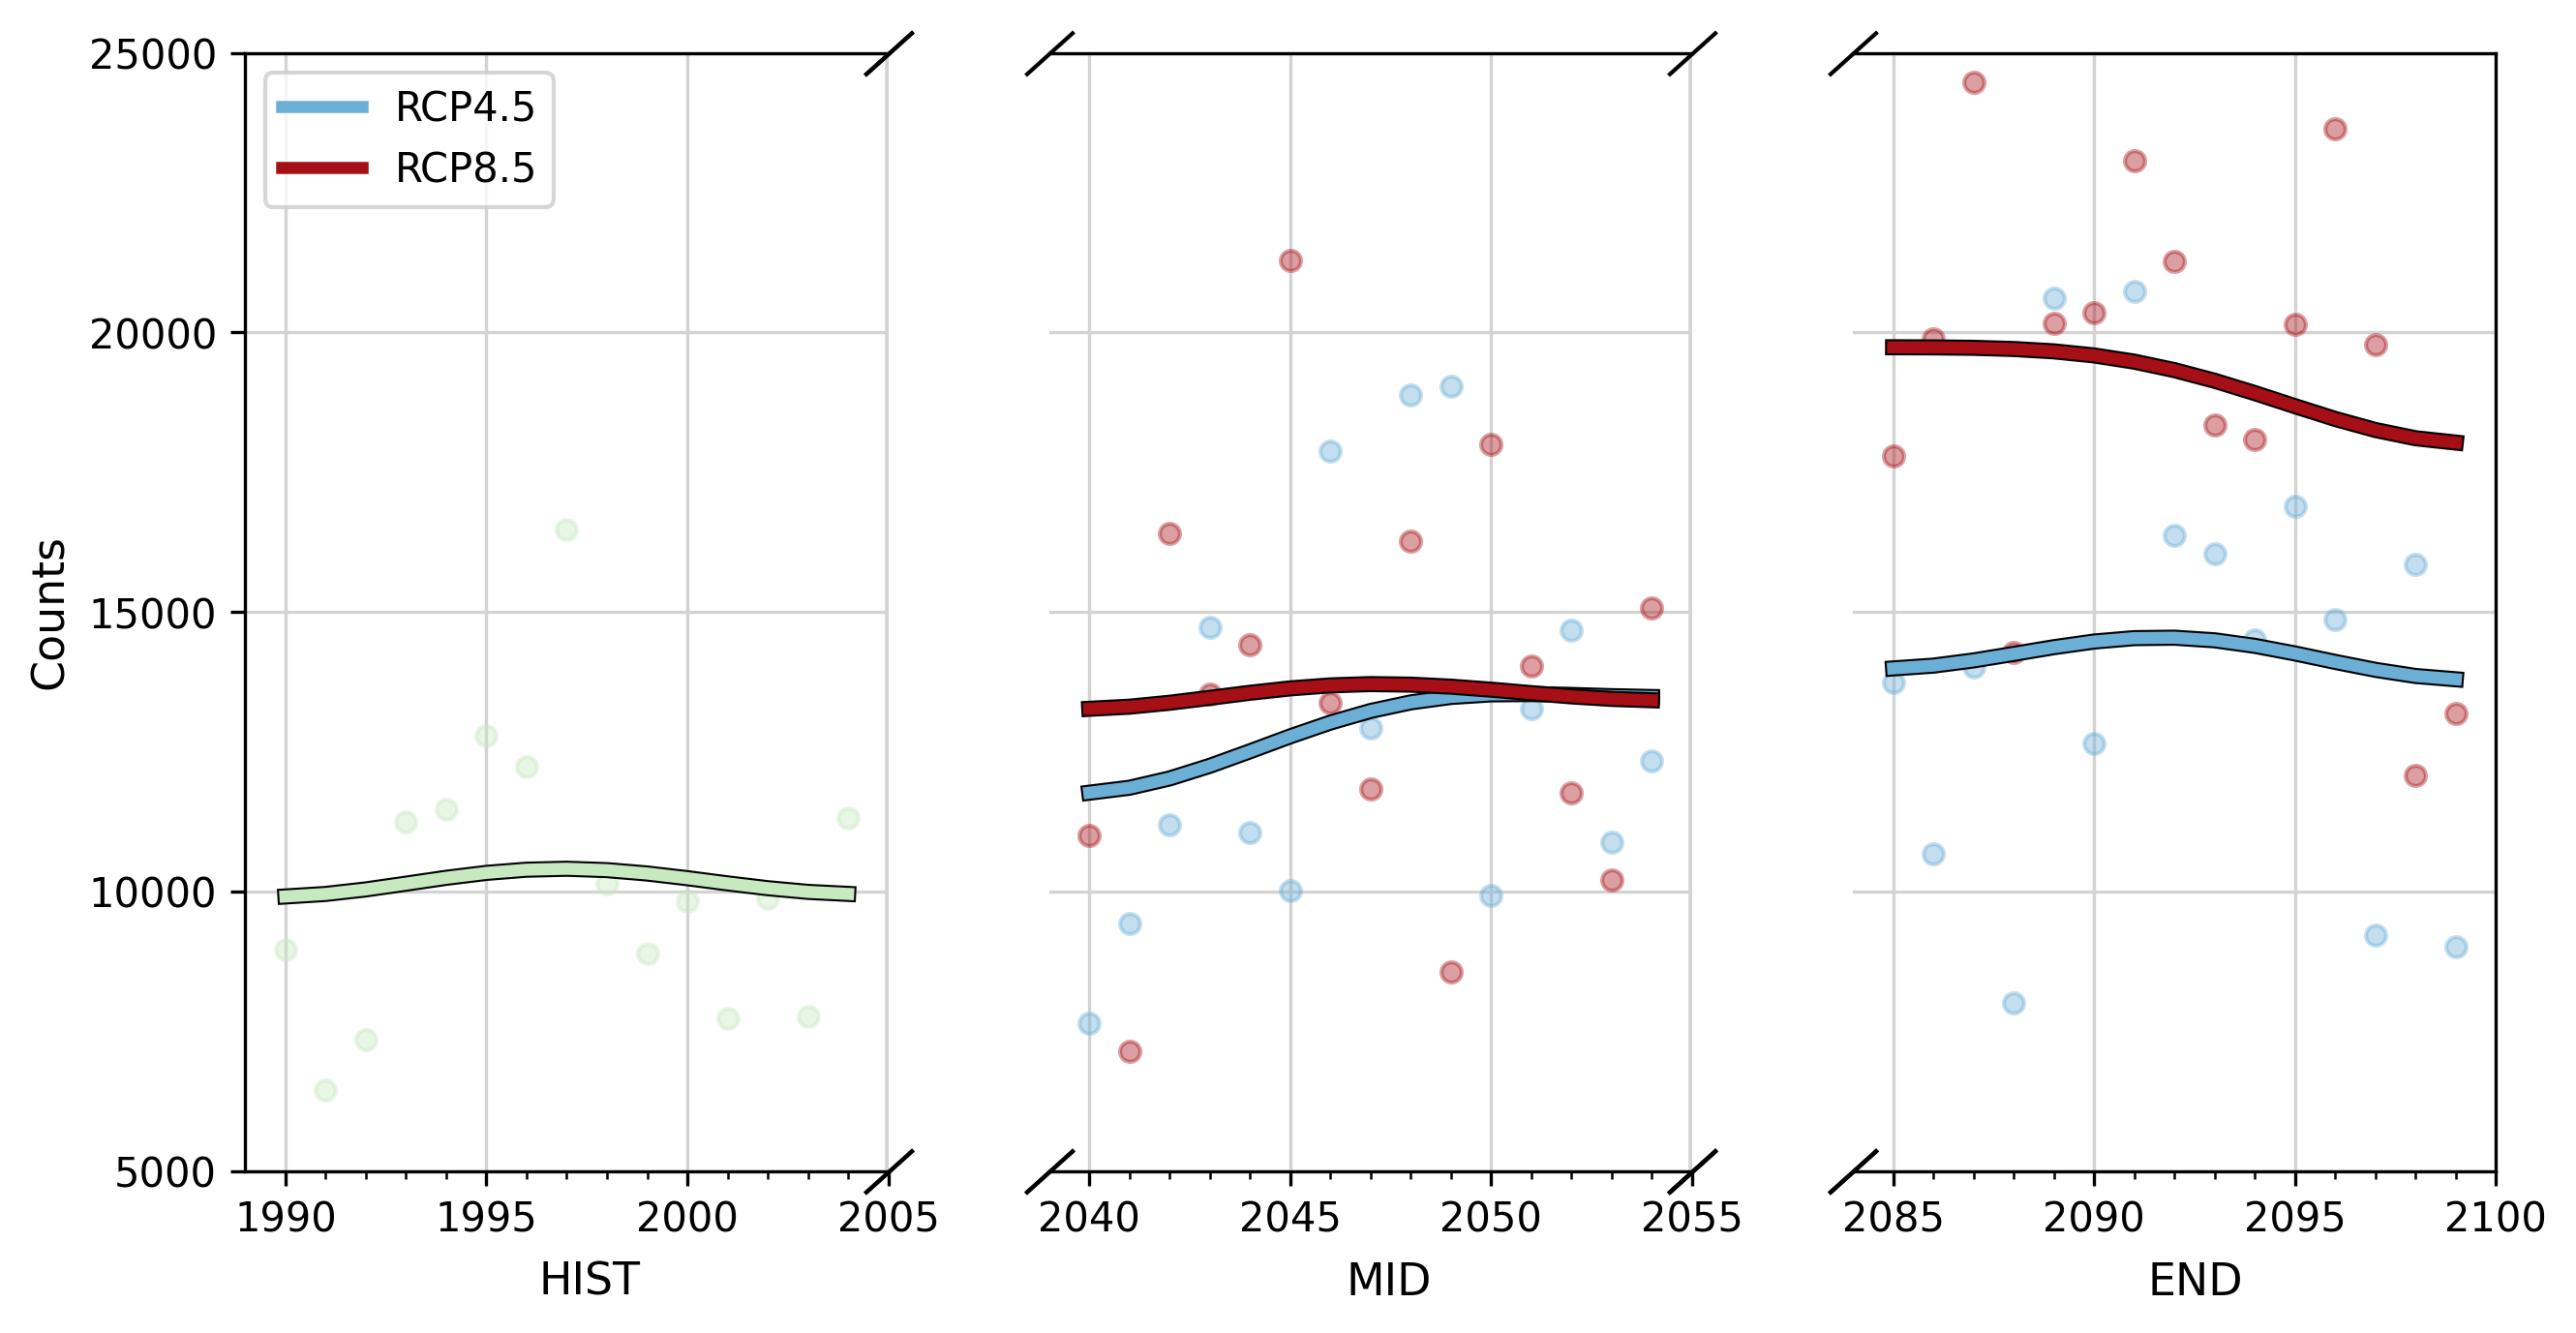

In [14]:
#figure specifications and plotting
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharex = False, figsize = (10, 5), dpi = 300)
fig.subplots_adjust(wspace = 0.25)

# ax2.set_title('Time Series SCW Counts', fontsize = 14, pad = 13)
# ax2.set_xlabel('Year', fontsize = 10)
ax1.set_ylabel('Counts', fontsize = 11)

#gaussian filter for fit lines
gaussian_HIST = gaussian_filter1d(sum_HIST.values, sigma = 5)
gaussian_4p5MID = gaussian_filter1d(sum_4p5MID.values, sigma = 5)
gaussian_8p5MID = gaussian_filter1d(sum_8p5MID.values, sigma = 5)
gaussian_4p5END = gaussian_filter1d(sum_4p5END.values, sigma = 5)
gaussian_8p5END = gaussian_filter1d(sum_8p5END.values, sigma = 5)

#raw data points
ax1.scatter(sum_HIST.index, sum_HIST.values, c = '#c7e9c0', alpha = 0.4, zorder = 2, s = 25)
ax2.scatter(sum_4p5MID.index, sum_4p5MID.values, c = '#6baed6', alpha = 0.4, zorder = 2, s = 25)
ax2.scatter(sum_8p5MID.index, sum_8p5MID.values, c = '#a50f15', alpha = 0.4, zorder = 2, s = 25)
ax3.scatter(sum_4p5END.index, sum_4p5END.values, c = '#6baed6', alpha = 0.4, zorder = 2, s = 25)
ax3.scatter(sum_8p5END.index, sum_8p5END.values, c = '#a50f15', alpha = 0.4, zorder = 2, s = 25)

#wider black smoothed lines
ax1.plot(sum_HIST.index, gaussian_HIST, c = 'black', lw = 4, zorder = 5)
ax2.plot(sum_4p5MID.index, gaussian_4p5MID, c = 'black', lw = 4, zorder = 5)
ax2.plot(sum_8p5MID.index, gaussian_8p5MID, c = 'black', lw = 4, zorder = 6)
ax3.plot(sum_4p5END.index, gaussian_4p5END, c = 'black', lw = 4, zorder = 5)
ax3.plot(sum_8p5END.index, gaussian_8p5END, c = 'black', lw = 4, zorder = 5)

#colored smoothed lines
ax1.plot(sum_HIST.index, gaussian_HIST, c = '#c7e9c0', label = 'HIST', lw = 3, zorder = 5)
ax2.plot(sum_4p5MID.index, gaussian_4p5MID, c = '#6baed6', label = 'MID4.5', lw = 3, zorder = 5)
ax2.plot(sum_8p5MID.index, gaussian_8p5MID, c = '#a50f15', label = 'MID8.5', lw = 3, zorder = 6)
ax3.plot(sum_4p5END.index, gaussian_4p5END, c = '#6baed6', label = 'END4.5', lw = 3, zorder = 5)
ax3.plot(sum_8p5END.index, gaussian_8p5END, c = '#a50f15', label = 'END8.5', lw = 3, zorder = 5)

ax1.set_ylim(5000, 25000)
ax2.set_ylim(5000, 25000)
ax3.set_ylim(5000, 25000)

ax2.tick_params(left = False, labelleft = False)
ax3.tick_params(left = False, labelleft = False)

ax1.set_xlim(1989, 2005)
ax2.set_xlim(2039, 2055)
ax3.set_xlim(2084, 2100)

ax1.spines.right.set_visible(False)
ax2.spines.right.set_visible(False)
ax2.spines.left.set_visible(False)
ax3.spines.left.set_visible(False)

d = 0.9
kwargs = dict(marker = [(-1, -d), (1, d)], markersize = 12, ls = 'none', c = 'k', mec = 'k', mew = 1, clip_on = False)

#axis break
ax1.plot([1, 1], [0, 0], transform = ax1.transAxes, **kwargs)
ax2.plot([0, 1], [0, 0], transform = ax2.transAxes, **kwargs)
ax2.plot([0, 1], [0, 0], transform = ax2.transAxes, **kwargs)
ax3.plot([0, 0], [0, 0], transform = ax3.transAxes, **kwargs)
ax1.plot([1, 1], [1, 1], transform = ax1.transAxes, **kwargs)
ax2.plot([1, 1], [1, 0], transform = ax2.transAxes, **kwargs)
ax2.plot([1, 0], [0, 1], transform = ax2.transAxes, **kwargs)
ax3.plot([0, 0], [0, 1], transform = ax3.transAxes, **kwargs)

yticks = np.arange(5000, 30000, 5000)
ax1.set_yticks(yticks)
ax2.set_yticks(yticks)
ax3.set_yticks(yticks)

minor_years_ax1 = np.arange(1990, 2006, 1)
ax1.set_xticks(minor_years_ax1, minor = True)
ax1.tick_params(axis = 'x', which = 'minor')

minor_years_ax2 = np.arange(2040, 2056, 1)
ax2.set_xticks(minor_years_ax2, minor = True)
ax2.tick_params(axis = 'x', which = 'minor')

minor_years_ax3 = np.arange(2085, 2101, 1)
ax3.set_xticks(minor_years_ax3, minor = True)
ax3.tick_params(axis = 'x', which = 'minor')

ax1.grid(True, color = 'lightgray')
ax2.grid(True, color = 'lightgray')
ax3.grid(True,  color = 'lightgray')

ax1.axvline(x = 2005, color = 'lightgray', lw = 1.8, zorder = 0.5)
ax2.axvline(x = 2055, color = 'lightgray', lw = 1.8, zorder = 0.5)

lines = [plt.Line2D([0], [0], color = '#6baed6', lw = 3), plt.Line2D([0], [0], color = '#a50f15', lw = 3)]
labels = ['RCP4.5', 'RCP8.5']

ax1.legend(lines, labels, loc = 'upper left')

plt.figtext(0.226, 0.025, 'HIST', fontsize = 11)
plt.figtext(0.504, 0.025, 'MID', fontsize = 11)
plt.figtext(0.78, 0.025, 'END', fontsize = 11)

plt.savefig('../Plots/time_series_count_gauss.png', dpi = 500, bbox_inches = 'tight')
plt.show()

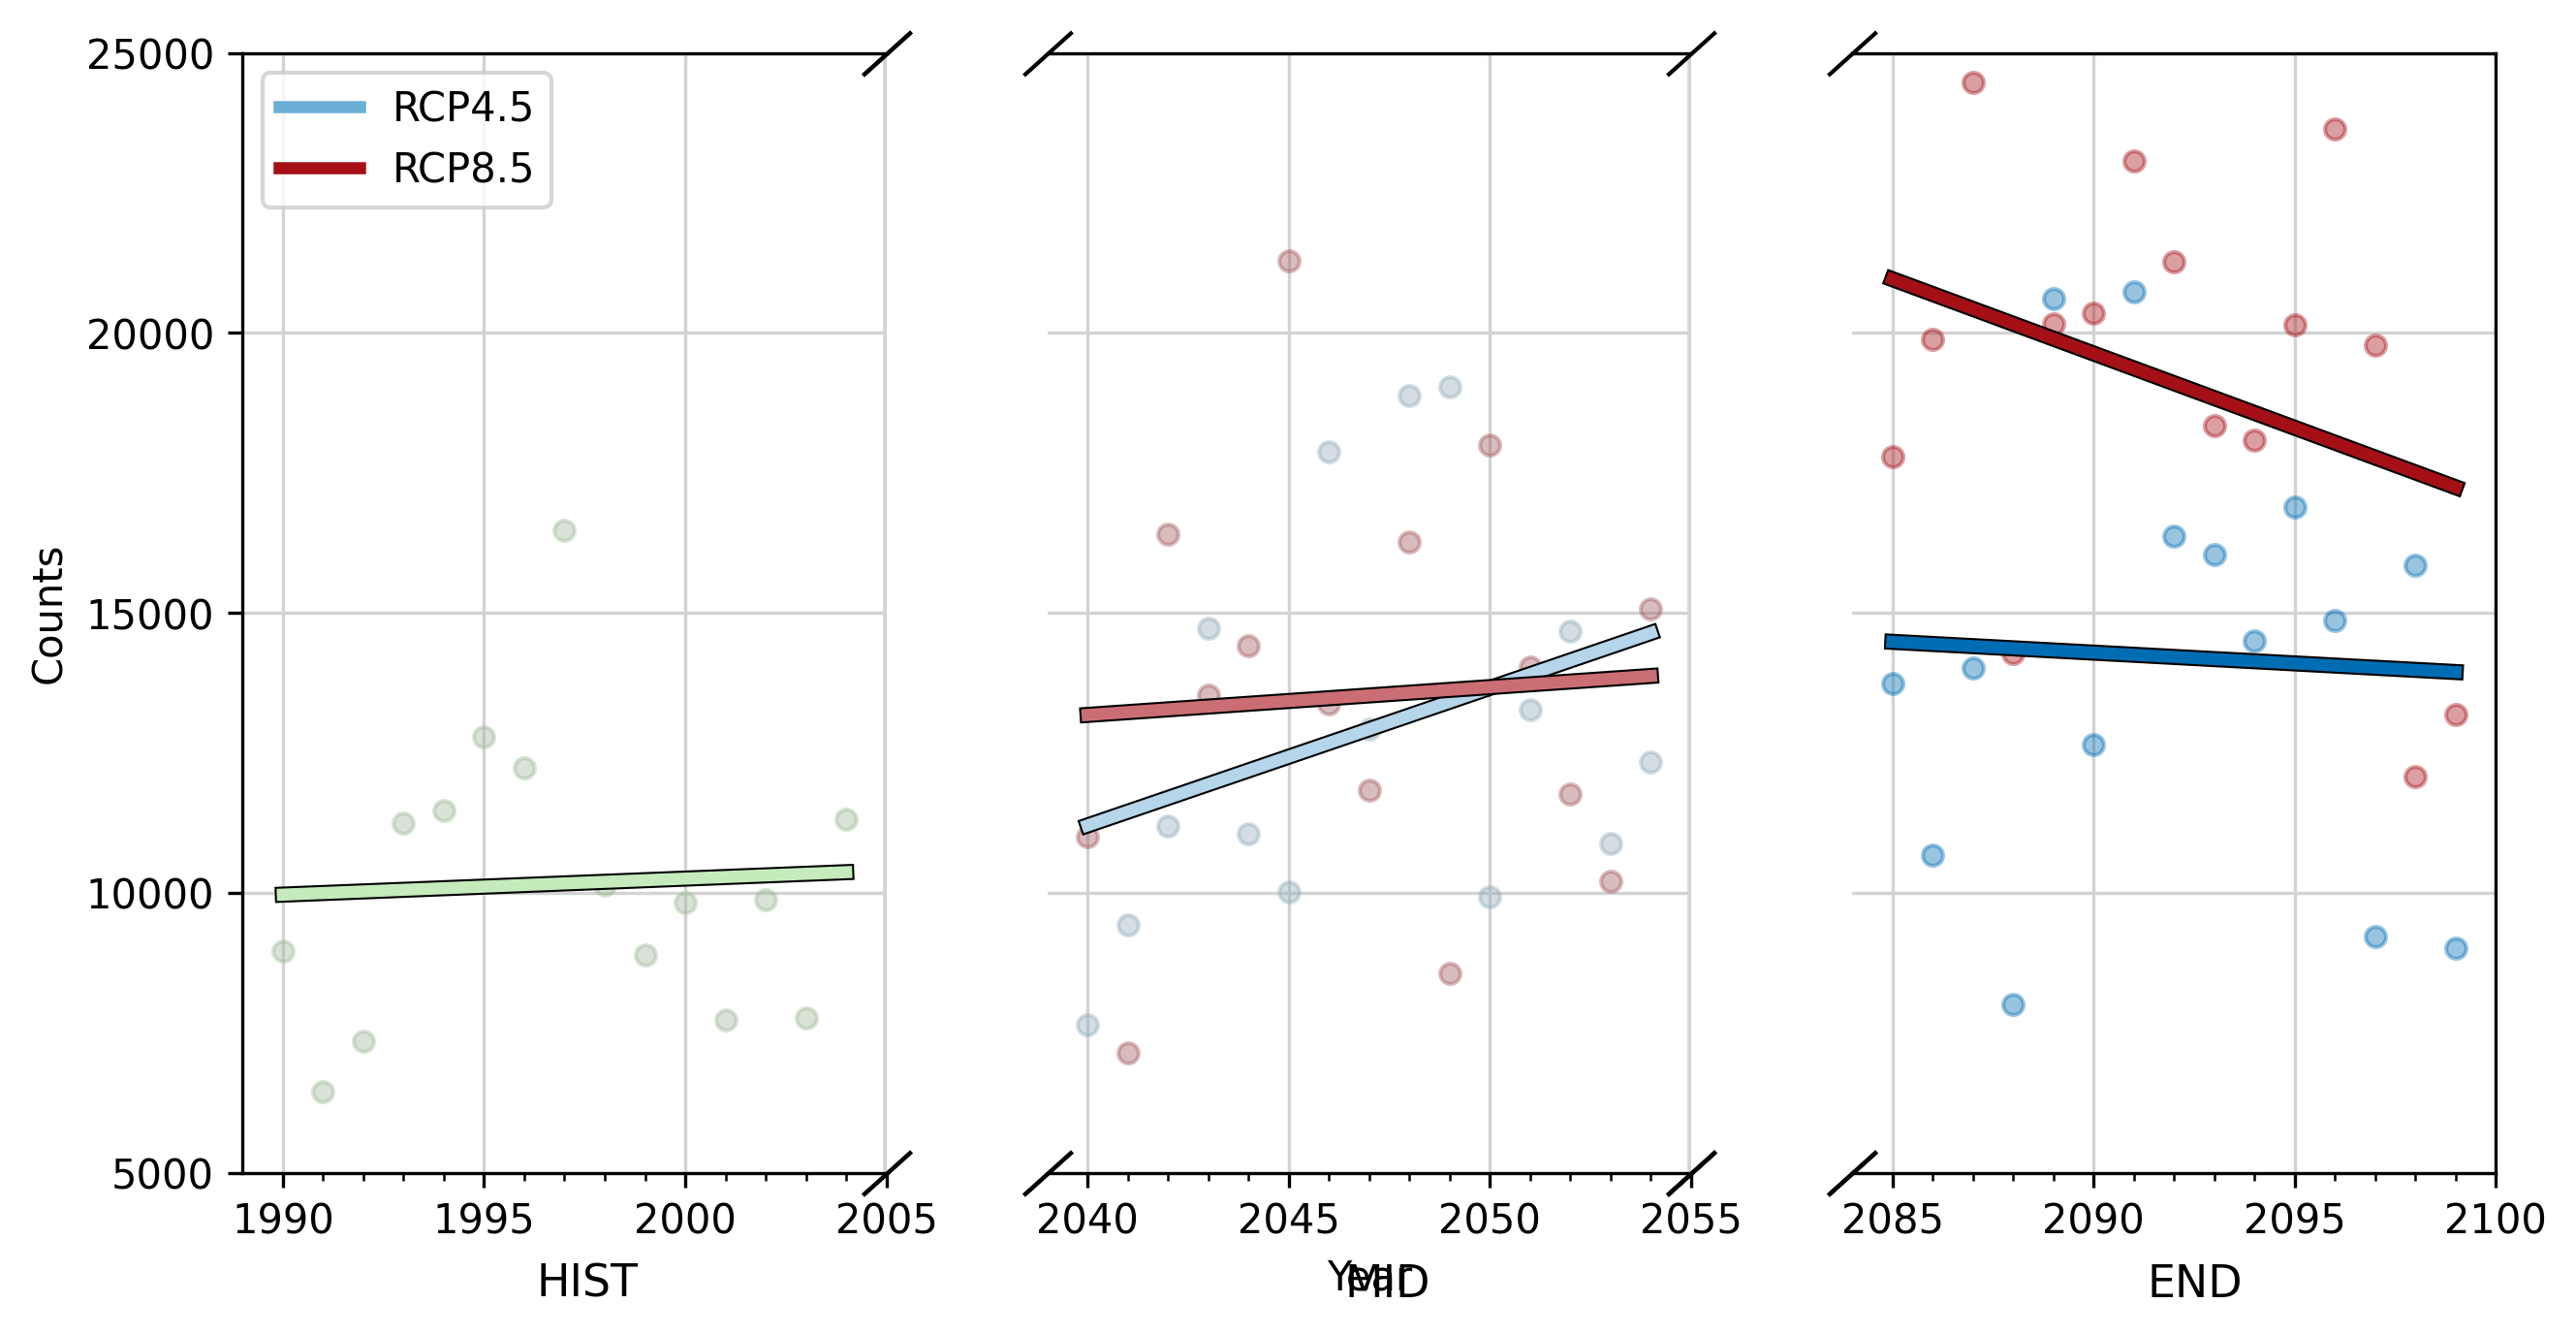

In [15]:
# timeseries w/ linear fit
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharex = False, figsize = (10, 5), dpi = 300)
fig.subplots_adjust(wspace = 0.25)

# ax2.set_title('Time Series SCW Counts', fontsize = 14, pad = 13)
ax2.set_xlabel('Year', fontsize = 10)
ax1.set_ylabel('Counts', fontsize = 10)

# linear fit, calcs slope and coeffs of data
linear_HIST = np.polyfit(sum_HIST.index, sum_HIST.values, 1)
linear_4p5MID = np.polyfit(sum_4p5MID.index, sum_4p5MID.values, 1)
linear_8p5MID = np.polyfit(sum_8p5MID.index, sum_8p5MID.values, 1)
linear_4p5END = np.polyfit(sum_4p5END.index, sum_4p5END.values, 1)
linear_8p5END = np.polyfit(sum_8p5END.index, sum_8p5END.values, 1)

#raw data points
ax1.scatter(sum_HIST.index, sum_HIST.values, c = '#9ebb96', alpha = 0.4, zorder = 2, s = 25)
ax2.scatter(sum_4p5MID.index, sum_4p5MID.values, c = '#91abbb', alpha = 0.4, zorder = 2, s = 25)
ax2.scatter(sum_8p5MID.index, sum_8p5MID.values, c = '#a2585d', alpha = 0.4, zorder = 2, s = 25)
ax3.scatter(sum_4p5END.index, sum_4p5END.values, c = '#006db3', alpha = 0.4, zorder = 2, s = 25)
ax3.scatter(sum_8p5END.index, sum_8p5END.values, c = '#a51017', alpha = 0.4, zorder = 2, s = 25)

# calc linear fit lines
years_HIST = np.arange(min(sum_HIST.index), max(sum_HIST.index) + 1)
years_4p5MID = np.arange(min(sum_4p5MID.index), max(sum_4p5MID.index) + 1)
years_8p5MID = np.arange(min(sum_8p5MID.index), max(sum_8p5MID.index) + 1)
years_4p5END = np.arange(min(sum_4p5END.index), max(sum_4p5END.index) + 1)
years_8p5END = np.arange(min(sum_8p5END.index), max(sum_8p5END.index) + 1)

fit_HIST = linear_HIST[0] * years_HIST + linear_HIST[1]
fit_4p5MID = linear_4p5MID[0] * years_4p5MID + linear_4p5MID[1]
fit_8p5MID = linear_8p5MID[0] * years_8p5MID + linear_8p5MID[1]
fit_4p5END = linear_4p5END[0] * years_4p5END + linear_4p5END[1]
fit_8p5END = linear_8p5END[0] * years_8p5END + linear_8p5END[1]

# plot wider black linear fit lines
ax1.plot(years_HIST, fit_HIST, c='black', lw=4, zorder=5)
ax2.plot(years_4p5MID, fit_4p5MID, c='black', lw=4, zorder=5)
ax2.plot(years_8p5MID, fit_8p5MID, c='black', lw=4, zorder=6)
ax3.plot(years_4p5END, fit_4p5END, c='black', lw=4, zorder=5)
ax3.plot(years_8p5END, fit_8p5END, c='black', lw=4, zorder=5)

# plot colored smoothed linear fit lines
ax1.plot(years_HIST, fit_HIST, c='#c5eabc', label='HIST', lw=3, zorder=5)
ax2.plot(years_4p5MID, fit_4p5MID, c='#b5d6ea', label='MID4.5', lw=3, zorder=5)
ax2.plot(years_8p5MID, fit_8p5MID, c='#ca6e74', label='MID8.5', lw=3, zorder=6)
ax3.plot(years_4p5END, fit_4p5END, c='#006db3', label='END4.5', lw=3, zorder=5)
ax3.plot(years_8p5END, fit_8p5END, c='#a51017', label='END8.5', lw=3, zorder=5)

ax1.set_ylim(5000, 25000)
ax2.set_ylim(5000, 25000)
ax3.set_ylim(5000, 25000)

ax2.tick_params(left = False, labelleft = False)
ax3.tick_params(left = False, labelleft = False)

ax1.set_xlim(1989, 2005)
ax2.set_xlim(2039, 2055)
ax3.set_xlim(2084, 2100)

ax1.spines.right.set_visible(False)
ax2.spines.right.set_visible(False)
ax2.spines.left.set_visible(False)
ax3.spines.left.set_visible(False)

d = 0.9
kwargs = dict(marker = [(-1, -d), (1, d)], markersize = 12, ls = 'none', c = 'k', mec = 'k', mew = 1, clip_on = False)

#axis break
ax1.plot([1, 1], [0, 0], transform = ax1.transAxes, **kwargs)
ax2.plot([0, 1], [0, 0], transform = ax2.transAxes, **kwargs)
ax2.plot([0, 1], [0, 0], transform = ax2.transAxes, **kwargs)
ax3.plot([0, 0], [0, 0], transform = ax3.transAxes, **kwargs)
ax1.plot([1, 1], [1, 1], transform = ax1.transAxes, **kwargs)
ax2.plot([1, 1], [1, 0], transform = ax2.transAxes, **kwargs)
ax2.plot([1, 0], [0, 1], transform = ax2.transAxes, **kwargs)
ax3.plot([0, 0], [0, 1], transform = ax3.transAxes, **kwargs)

yticks = np.arange(5000, 30000, 5000)
ax1.set_yticks(yticks)
ax2.set_yticks(yticks)
ax3.set_yticks(yticks)

minor_years_ax1 = np.arange(1990, 2006, 1)
ax1.set_xticks(minor_years_ax1, minor = True)
ax1.tick_params(axis = 'x', which = 'minor')

minor_years_ax2 = np.arange(2040, 2056, 1)
ax2.set_xticks(minor_years_ax2, minor = True)
ax2.tick_params(axis = 'x', which = 'minor')

minor_years_ax3 = np.arange(2085, 2101, 1)
ax3.set_xticks(minor_years_ax3, minor = True)
ax3.tick_params(axis = 'x', which = 'minor')

ax1.grid(True, color = 'lightgray')
ax2.grid(True, color = 'lightgray')
ax3.grid(True,  color = 'lightgray')

ax1.axvline(x = 2005, color = 'lightgray', lw = 1.8, zorder = 0.5)
ax2.axvline(x = 2055, color = 'lightgray', lw = 1.8, zorder = 0.5)

lines = [plt.Line2D([0], [0], color = '#6baed6', lw = 3), plt.Line2D([0], [0], color = '#a50f15', lw = 3)]
labels = ['RCP4.5', 'RCP8.5']

ax1.legend(lines, labels, loc = 'upper left')

plt.figtext(0.226, 0.025, 'HIST', fontsize = 11)
plt.figtext(0.504, 0.025, 'MID', fontsize = 11)
plt.figtext(0.78, 0.025, 'END', fontsize = 11)

#plt.savefig('time_series_counts_linear.png', dpi = 500, bbox_inches = 'tight')
plt.show()

In [16]:
# function to convert water year to calendar year and output daily count
def water_calendar_year(df):

    daily_counts = pd.DataFrame(index=np.arange(1,366,1))
    df['Day_of_Year'] = pd.to_datetime(df['Date']).dt.dayofyear
    
    for year in df['Year'].unique()[:-1]:
        b=[]
        
        if year == np.min(df['Year'].unique()):
            df_year = df[((df['Year'] == np.min(df['Year'].unique())) | (df['Year'] == np.max(df['Year'].unique())))]
            
            for day in np.arange(1,366,1):
                df_sub = df_year[(df_year['Day_of_Year'] == day)]
                b.append(len(df_sub))
            
            
        else:
            df_year = df[(df['Year'] == year)]
            
            for day in np.arange(1,366,1):
                df_sub = df_year[(df_year['Day_of_Year'] == day)]
                b.append(len(df_sub))
            
        daily_counts[year] = b
            
    return daily_counts

### HCW Days Timeseries

In [17]:
# calc daily counts for each epoch and convert to calendar year
new_df_HIST = water_calendar_year(df_HIST)
new_df_4p5MID = water_calendar_year(df_4p5MID)
new_df_8p5MID = water_calendar_year(df_8p5MID)
new_df_4p5END = water_calendar_year(df_4p5END)
new_df_8p5END = water_calendar_year(df_8p5END)

In [18]:
# sum daily count for each epoch
hcw_days_HIST = (new_df_HIST > 0).sum()
hcw_days_4p5MID = (new_df_4p5MID > 0).sum()
hcw_days_8p5MID = (new_df_8p5MID > 0).sum()
hcw_days_4p5END = (new_df_4p5END > 0).sum()
hcw_days_8p5END = (new_df_8p5END > 0).sum()

In [19]:
# gaussian fit
gaussian_HIST_days = gaussian_filter1d(hcw_days_HIST.values, sigma=5)
gaussian_4p5MID_days = gaussian_filter1d(hcw_days_4p5MID.values, sigma=5)
gaussian_8p5MID_days = gaussian_filter1d(hcw_days_8p5MID.values, sigma=5)
gaussian_4p5END_days = gaussian_filter1d(hcw_days_4p5END.values, sigma=5)
gaussian_8p5END_days = gaussian_filter1d(hcw_days_8p5END.values, sigma=5)

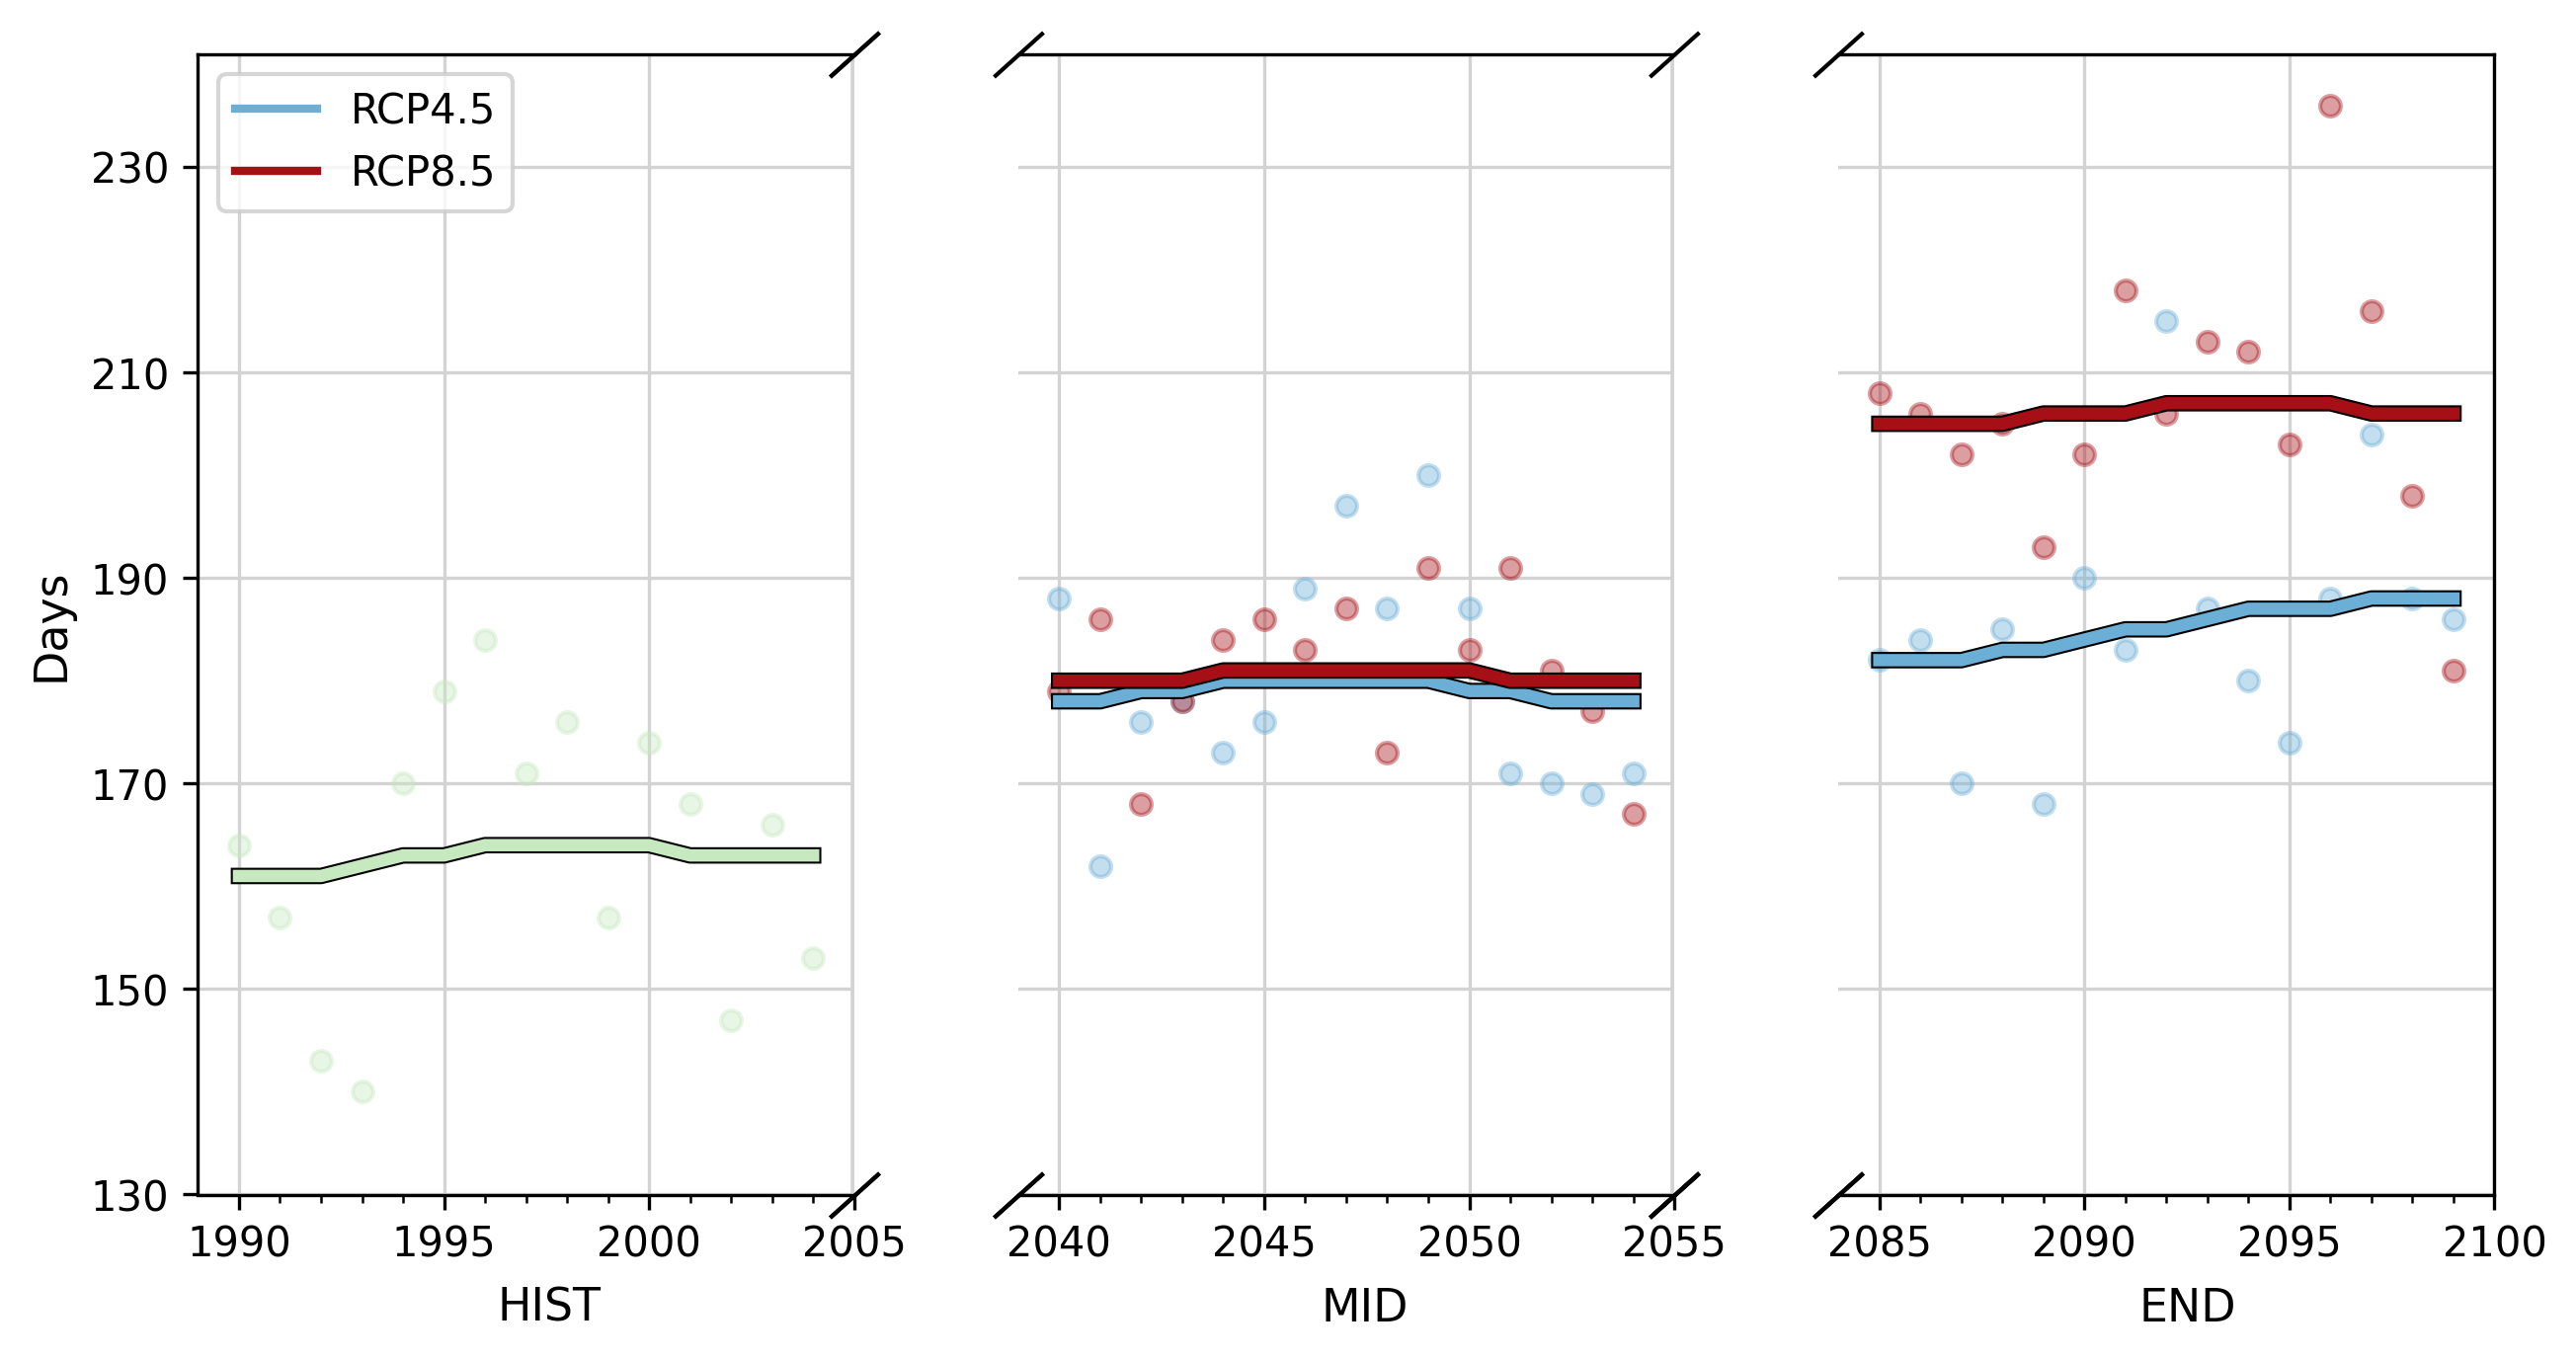

In [20]:
# time series HCW days
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharex=False, figsize=(10, 5), dpi=300)
fig.subplots_adjust(wspace=0.25)

# ax2.set_title('Time Series SCW Days', fontsize=14, pad=13)
# ax2.set_xlabel('Year', fontsize=10)
ax1.set_ylabel('Days', fontsize=11)

# annual days scatter plot
ax1.scatter(hcw_days_HIST.index, hcw_days_HIST.values, c='#c7e9c0', alpha=0.4, zorder=2, s=25)
ax2.scatter(hcw_days_4p5MID.index, hcw_days_4p5MID.values, c='#6baed6', alpha=0.4, zorder=2, s=25)
ax2.scatter(hcw_days_8p5MID.index, hcw_days_8p5MID.values, c='#a50f15', alpha=0.4, zorder=2, s=25)
ax3.scatter(hcw_days_4p5END.index, hcw_days_4p5END.values, c='#6baed6', alpha=0.4, zorder=2, s=25)
ax3.scatter(hcw_days_8p5END.index, hcw_days_8p5END.values, c='#a50f15', alpha=0.4, zorder=2, s=25)

# gaussian fit - wider black smoothed lines
ax1.plot(hcw_days_HIST.index, gaussian_HIST_days, c='black', lw=4, zorder=5)
ax2.plot(hcw_days_4p5MID.index, gaussian_4p5MID_days, c='black', lw=4, zorder=5)
ax2.plot(hcw_days_8p5MID.index, gaussian_8p5MID_days, c='black', lw=4, zorder=6)
ax3.plot(hcw_days_4p5END.index, gaussian_4p5END_days, c='black', lw=4, zorder=5)
ax3.plot(hcw_days_8p5END.index, gaussian_8p5END_days, c='black', lw=4, zorder=5)

# gaussian fit - colored smoothed lines
ax1.plot(hcw_days_HIST.index, gaussian_HIST_days, c='#c7e9c0', label='HIST', lw=3, zorder=5)
ax2.plot(hcw_days_4p5MID.index, gaussian_4p5MID_days, c='#6baed6', label='MID4.5', lw=3, zorder=5)
ax2.plot(hcw_days_8p5MID.index, gaussian_8p5MID_days, c='#a50f15', label='MID8.5', lw=3, zorder=6)
ax3.plot(hcw_days_4p5END.index, gaussian_4p5END_days, c='#6baed6', label='END4.5', lw=3, zorder=5)
ax3.plot(hcw_days_8p5END.index, gaussian_8p5END_days, c='#a50f15', label='END8.5', lw=3, zorder=5)

ax1.set_ylim(130, 241)  
ax2.set_ylim(130, 241)
ax3.set_ylim(130, 241)

ax2.tick_params(left = False, labelleft = False)
ax3.tick_params(left = False, labelleft = False)

ax1.set_xlim(1989, 2005)
ax2.set_xlim(2039, 2055)
ax3.set_xlim(2084, 2100)

ax1.spines.right.set_visible(False)
ax2.spines.right.set_visible(False)
ax2.spines.left.set_visible(False)
ax3.spines.left.set_visible(False)

d = 0.9
kwargs = dict(marker = [(-1, -d), (1, d)], markersize = 12, ls = 'none', c = 'k', mec = 'k', mew = 1, clip_on = False)

#axis break
ax1.plot([1, 1], [0, 0], transform = ax1.transAxes, **kwargs)
ax2.plot([0, 1], [0, 0], transform = ax2.transAxes, **kwargs)
ax2.plot([0, 1], [0, 0], transform = ax2.transAxes, **kwargs)
ax3.plot([0, 0], [0, 0], transform = ax3.transAxes, **kwargs)
ax1.plot([1, 1], [1, 1], transform = ax1.transAxes, **kwargs)
ax2.plot([1, 1], [1, 0], transform = ax2.transAxes, **kwargs)
ax2.plot([1, 0], [0, 1], transform = ax2.transAxes, **kwargs)
ax3.plot([0, 0], [0, 1], transform = ax3.transAxes, **kwargs)

yticks = np.arange(130, 241, 20)
ax1.set_yticks(yticks)
ax2.set_yticks(yticks)
ax3.set_yticks(yticks)

minor_years_ax1 = np.arange(1990, 2006, 1)
ax1.set_xticks(minor_years_ax1, minor = True)
ax1.tick_params(axis = 'x', which = 'minor')

minor_years_ax2 = np.arange(2040, 2056, 1)
ax2.set_xticks(minor_years_ax2, minor = True)
ax2.tick_params(axis = 'x', which = 'minor')

minor_years_ax3 = np.arange(2085, 2101, 1)
ax3.set_xticks(minor_years_ax3, minor = True)
ax3.tick_params(axis = 'x', which = 'minor')

ax1.grid(True, color = 'lightgray')
ax2.grid(True, color = 'lightgray')
ax3.grid(True,  color = 'lightgray')

ax1.axvline(x = 2005, color = 'lightgray', lw = 1.8, zorder = 0.5)
ax2.axvline(x = 2055, color = 'lightgray', lw = 1.8, zorder = 0.5)

lines = [plt.Line2D([0], [0], color = '#6baed6', lw = 2), plt.Line2D([0], [0], color = '#a50f15', lw = 2)]
labels = ['RCP4.5', 'RCP8.5']

ax1.legend(lines, labels, loc = 'upper left')

plt.figtext(0.226, 0.025, 'HIST', fontsize = 11)
plt.figtext(0.504, 0.025, 'MID', fontsize = 11)
plt.figtext(0.78, 0.025, 'END', fontsize = 11)

plt.savefig('../Plots/time_series_days.png', dpi = 500, bbox_inches = 'tight')
plt.show()